실습 문제. 제품 생산 계획 최적화

모델링

- 원문제    
max z = 40P+50Q+60R  
s.t. 2P+Q+3R <=120   
     P+2Q+2R<=80   
     P+3Q+R<=100    
     P,Q,R>=0

- 쌍대문제  
min z=120y1+80y2+100y3  
s.t. 2y1+y2+y3 >= 40  
     y1+2y2+3y3 >= 50
     3y1+2y2+1y3 >= 60    
     y1,y2>=0

In [20]:
from ortools.linear_solver import pywraplp

# 솔버 생성 (GLOP = Google LP solver)
solver = pywraplp.Solver.CreateSolver('GLOP')

# 결정 변수
INF = solver.infinity()
P = solver.NumVar(0,INF,'P') # 제품P 생산량
Q = solver.NumVar(0,INF, 'Q') # 제품Q 생산량
R = solver.NumVar(0,INF, 'R') # 제품R 생산량

# 제약 조건
c1 = solver.Add(2*P+Q+3*R <=120, '원자재_제약')
c2 = solver.Add(P+2*Q+2*R<=80,'노동력_제약')
c3 = solver.Add(P+3*Q+R<=100,'기계_제약')

# 목적 함수
solver.Maximize(40*P+50*Q+60*R )

# 풀기
status = solver.Solve()

STATUS_NAME = {
    pywraplp.Solver.OPTIMAL: 'OPTIMAL',
    pywraplp.Solver.FEASIBLE: 'FEASIBLE (not optimal)',
    pywraplp.Solver.INFEASIBLE: 'INFEASIBLE',
    pywraplp.Solver.UNBOUNDED: 'UNBOUNDED',
}

print('='*45)
print(f'상태: {STATUS_NAME.get(status, status)}')
print('='*45)

if status == pywraplp.Solver.OPTIMAL:
    print(f'제품 P: {P.solution_value():.4f}개')
    print(f'제품 Q: {Q.solution_value():.4f}개')
    print(f'제품 R: {R.solution_value():.4f}개')
    print(f'최대 이익 : {solver.Objective().Value():.4f} 만원')
    print('-'*45)
    print('[쌍대값 / Shadow Price]')
    print(f'y1 (원자재 제약): {c1.dual_value():.4f} kg/개')
    print(f'y2 (노동력 제약): {c2.dual_value():.4f} h/개')
    print(f'y3 (기계 제약): {c3.dual_value():.4f} h/개')
    print('-'*45)
    print('[Slack (여유)]')
    print(f'rc(P): {P.reduced_cost():.4f}')
    print(f'rc(Q): {Q.reduced_cost():.4f}')
    print(f'rc(R): {R.reduced_cost():.4f}')
    # print(100-P.solution_value()-3*Q.solution_value()-R.solution_value())

상태: OPTIMAL
제품 P: 53.3333개
제품 Q: 13.3333개
제품 R: 0.0000개
최대 이익 : 2800.0000 만원
---------------------------------------------
[쌍대값 / Shadow Price]
y1 (원자재 제약): 10.0000 kg/개
y2 (노동력 제약): 20.0000 h/개
y3 (기계 제약): -0.0000 h/개
---------------------------------------------
[Slack (여유)]
rc(P): 0.0000
rc(Q): 0.0000
rc(R): -10.0000


In [ ]:
import platform
import matplotlib.pyplot as plt

if platform.system() =='Windows':
    plt.rcParams['font.family'] = 'NanumGothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

목적함수 계수 민감도 - c1~3(제품P~R이익) 변화

In [6]:
import warnings
warnings.filterwarnings('ignore')

c1(제품P이익) 변화

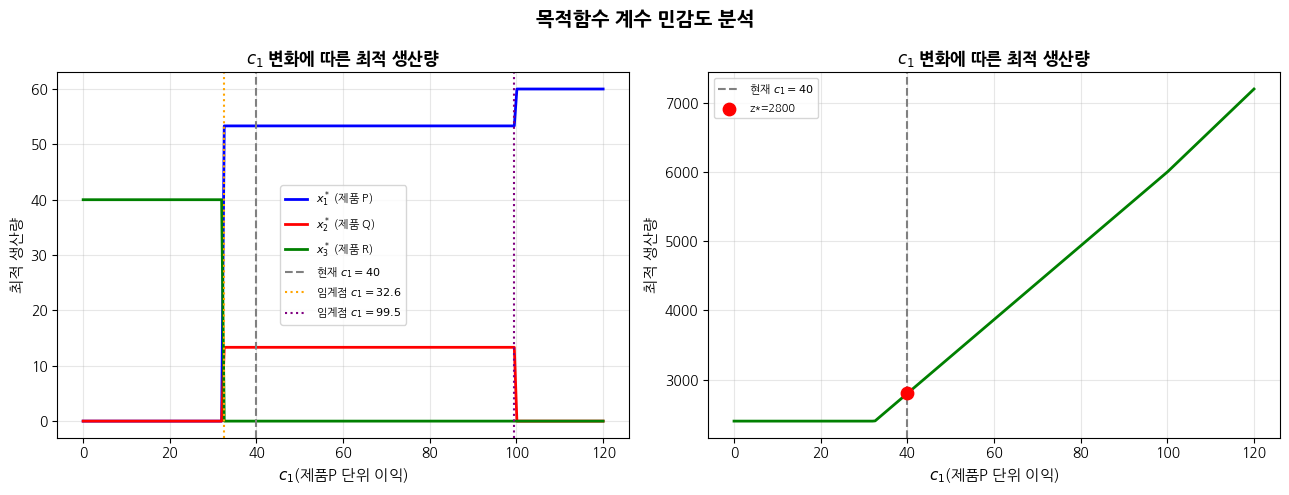

c1의 허용 범위: 32.6<=c1<=99.5(현재 기저 유지)
c1<32.6 -> 기저 변경: x1=0, x2=0, x3=40 이 최적
c1>99.5 -> 기저 변경: x1=59.9, x2=0, x3=0이 최적


In [42]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

def solve_lp(c1_val, c2_val=50, c3_val=60, b1=120, b2=80, b3=100):
    #LP를 주어진 파라미터로 풀고 (x1,x2,z) 반환
    s = pywraplp.Solver.CreateSolver('GLOP')
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')
    
    s.Add(2*P+Q+3*R <= b1)
    s.Add(P+2*Q+2*R <= b2)
    s.Add(P+3*Q+1*R <= b3)
    s.Maximize(c1_val*P + c2_val*Q + c3_val*R)
    
    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        return P.solution_value(), Q.solution_value(), R.solution_value(), s.Objective().Value()
    
    return None, None, None

c1_range = np.linspace(0,120,200)
x1_vals, x2_vals, x3_vals, z_vals = [], [], [], []
for c1v in c1_range:
    xv1, xv2, xv3, zv = solve_lp(c1v)
    x1_vals.append(xv1); x2_vals.append(xv2); x3_vals.append(xv3); z_vals.append(zv)
    # if (xv2 == 0)&(xv3 == 0):
    #     print(xv1)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.plot(c1_range, x1_vals, 'b-', lw=2, label=r'$x_1^*$ (제품 P)')
ax.plot(c1_range, x2_vals, 'r-', lw=2, label=r'$x_2^*$ (제품 Q)')
ax.plot(c1_range, x3_vals, 'g-', lw=2, label=r'$x_3^*$ (제품 R)')
ax.axvline(40,color='gray', ls='--', label='현재 $c_1=40$')
ax.axvline(32.6,color='orange', ls=':', lw=1.5, label='임계점 $c_1=32.6$')
ax.axvline(99.5,color='purple', ls=':', lw=1.5, label='임계점 $c_1=99.5$')
ax.set_xlabel(r'$c_1$(제품P 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_1$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(c1_range, z_vals, 'g-', lw=2)
ax.axvline(40, color='gray', ls='--', label='현재 $c_1=40$')
ax.scatter([40],[2800],color='red', s=80, zorder=5, label='z*=2800')
ax.set_xlabel(r'$c_1$(제품P 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_1$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('목적함수 계수 민감도 분석', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('c1의 허용 범위: 32.6<=c1<=99.5(현재 기저 유지)')
print('c1<32.6 -> 기저 변경: x1=0, x2=0, x3=40 이 최적')
print('c1>99.5 -> 기저 변경: x1=59.9, x2=0, x3=0이 최적')


c2(제품Q이익) 변화

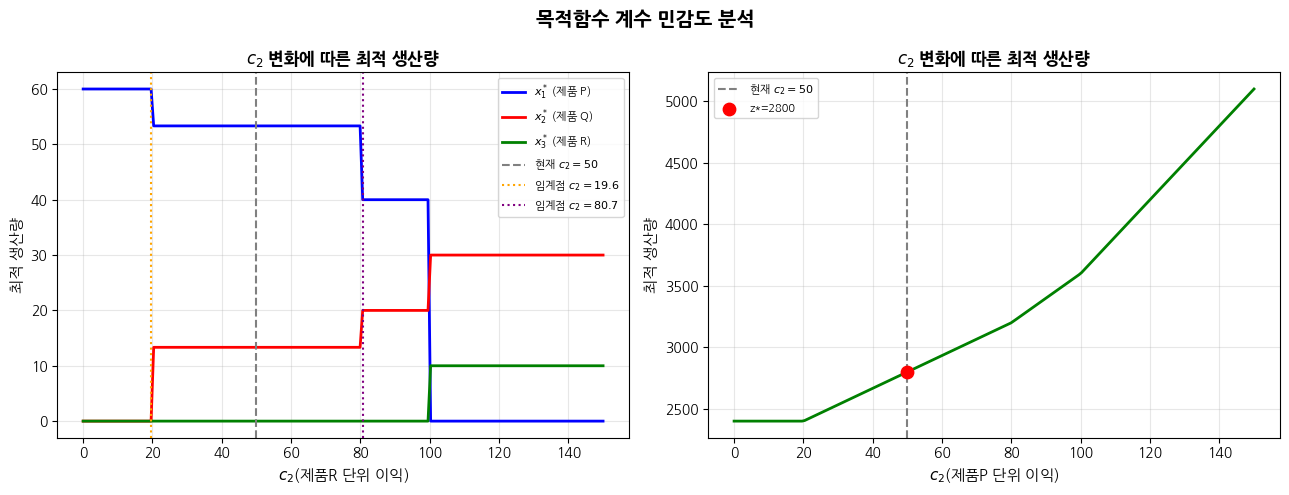

c2의 허용 범위: 32.6<=c2<=99.5(현재 기저 유지)
c2<19.6 -> 기저 변경: x1=59.9, x2=0, x3=0 이 최적
c2>80.7 -> 기저 변경: x1=0, x2=40, x3=0이 최적
c2>100 -> 기저 변경: x1=0, x2=30, x3=10이 최적


In [44]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

def solve_lp(c2_val, c1_val=40, c3_val=60, b1=120, b2=80, b3=100):
    #LP를 주어진 파라미터로 풀고 (x1,x2,z) 반환
    s = pywraplp.Solver.CreateSolver('GLOP')
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')
    
    s.Add(2*P+Q+3*R <= b1)
    s.Add(P+2*Q+2*R <= b2)
    s.Add(P+3*Q+1*R <= b3)
    s.Maximize(c1_val*P + c2_val*Q + c3_val*R)
    
    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        return P.solution_value(), Q.solution_value(), R.solution_value(), s.Objective().Value()
    
    return None, None, None

c2_range = np.linspace(0,150,200)
x1_vals, x2_vals, x3_vals, z_vals = [], [], [], []
for c2v in c2_range:
    xv1, xv2, xv3, zv = solve_lp(c2v)
    x1_vals.append(xv1); x2_vals.append(xv2); x3_vals.append(xv3); z_vals.append(zv)
    # if c2v <= 50:
    #     print(zv)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.plot(c2_range, x1_vals, 'b-', lw=2, label=r'$x_1^*$ (제품 P)')
ax.plot(c2_range, x2_vals, 'r-', lw=2, label=r'$x_2^*$ (제품 Q)')
ax.plot(c2_range, x3_vals, 'g-', lw=2, label=r'$x_3^*$ (제품 R)')
ax.axvline(50,color='gray', ls='--', label='현재 $c_2=50$')
ax.axvline(19.6,color='orange', ls=':', lw=1.5, label='임계점 $c_2=19.6$')
ax.axvline(80.7,color='purple', ls=':', lw=1.5, label='임계점 $c_2=80.7$')
ax.set_xlabel(r'$c_2$(제품R 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_2$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(c2_range, z_vals, 'g-', lw=2)
ax.axvline(50, color='gray', ls='--', label='현재 $c_2=50$')
ax.scatter([50],[2800],color='red', s=80, zorder=5, label='z*=2800')
ax.set_xlabel(r'$c_2$(제품P 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_2$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('목적함수 계수 민감도 분석', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('c2의 허용 범위: 32.6<=c2<=99.5(현재 기저 유지)')
print('c2<19.6 -> 기저 변경: x1=59.9, x2=0, x3=0 이 최적')
print('c2>80.7 -> 기저 변경: x1=0, x2=40, x3=0이 최적')
print('c2>100 -> 기저 변경: x1=0, x2=30, x3=10이 최적')


c3(제품R이익) 변화

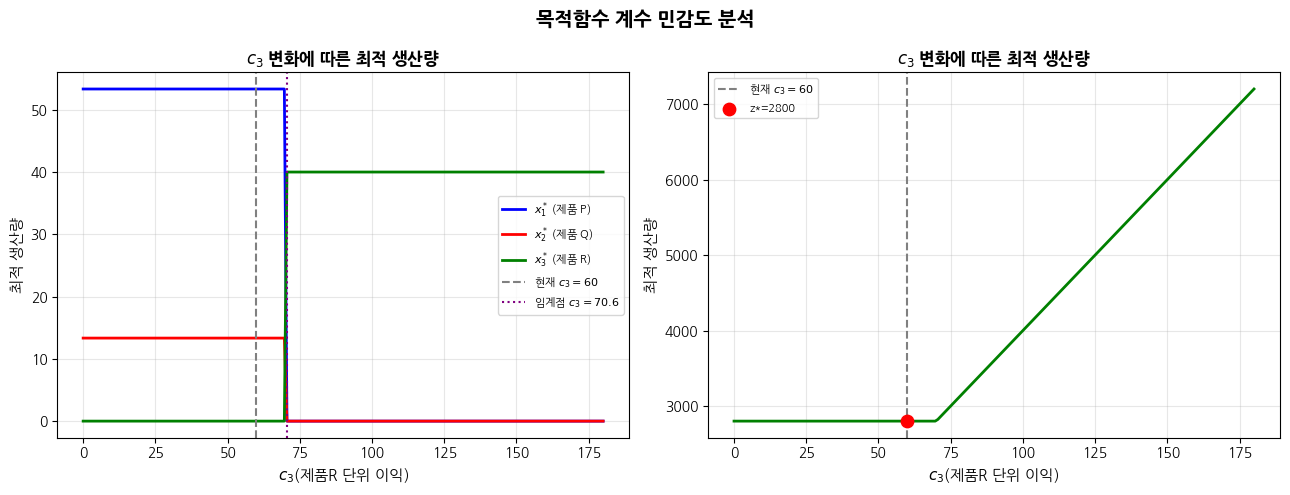

c1의 허용 범위: c3<=70.6(현재 기저 유지)
c3>70.6 -> 기저 변경: x1=0, x2=0, x3=39.9이 최적


In [45]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

def solve_lp(c3_val, c1_val=40, c2_val=50, b1=120, b2=80, b3=100):
    #LP를 주어진 파라미터로 풀고 (x1,x2,z) 반환
    s = pywraplp.Solver.CreateSolver('GLOP')
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')
    
    s.Add(2*P+Q+3*R <= b1)
    s.Add(P+2*Q+2*R <= b2)
    s.Add(P+3*Q+1*R <= b3)
    s.Maximize(c1_val*P + c2_val*Q + c3_val*R)
    
    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        return P.solution_value(), Q.solution_value(), R.solution_value(), s.Objective().Value()
    
    return None, None, None

c3_range = np.linspace(0,180,200)
x1_vals, x2_vals, x3_vals, z_vals = [], [], [], []
for c3v in c3_range:
    xv1, xv2, xv3, zv = solve_lp(c3v)
    x1_vals.append(xv1); x2_vals.append(xv2); x3_vals.append(xv3); z_vals.append(zv)
    # if xv1 == 0:
    #     print(xv3)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.plot(c3_range, x1_vals, 'b-', lw=2, label=r'$x_1^*$ (제품 P)')
ax.plot(c3_range, x2_vals, 'r-', lw=2, label=r'$x_2^*$ (제품 Q)')
ax.plot(c3_range, x3_vals, 'g-', lw=2, label=r'$x_3^*$ (제품 R)')
ax.axvline(60,color='gray', ls='--', label='현재 $c_3=60$')
ax.axvline(70.6,color='purple', ls=':', lw=1.5, label='임계점 $c_3=70.6$')
ax.set_xlabel(r'$c_3$(제품R 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_3$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(c3_range, z_vals, 'g-', lw=2)
ax.axvline(60, color='gray', ls='--', label='현재 $c_3=60$')
ax.scatter([60],[2800],color='red', s=80, zorder=5, label='z*=2800')
ax.set_xlabel(r'$c_3$(제품R 단위 이익)', fontsize=11)
ax.set_ylabel('최적 생산량', fontsize=11)
ax.set_title(r'$c_3$ 변화에 따른 최적 생산량', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('목적함수 계수 민감도 분석', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('c1의 허용 범위: c3<=70.6(현재 기저 유지)')
print('c3>70.6 -> 기저 변경: x1=0, x2=0, x3=39.9이 최적')


RHS 민감도 - Shadow Price 유효 범위 - 제약식 b1~3 변화

b1 변화

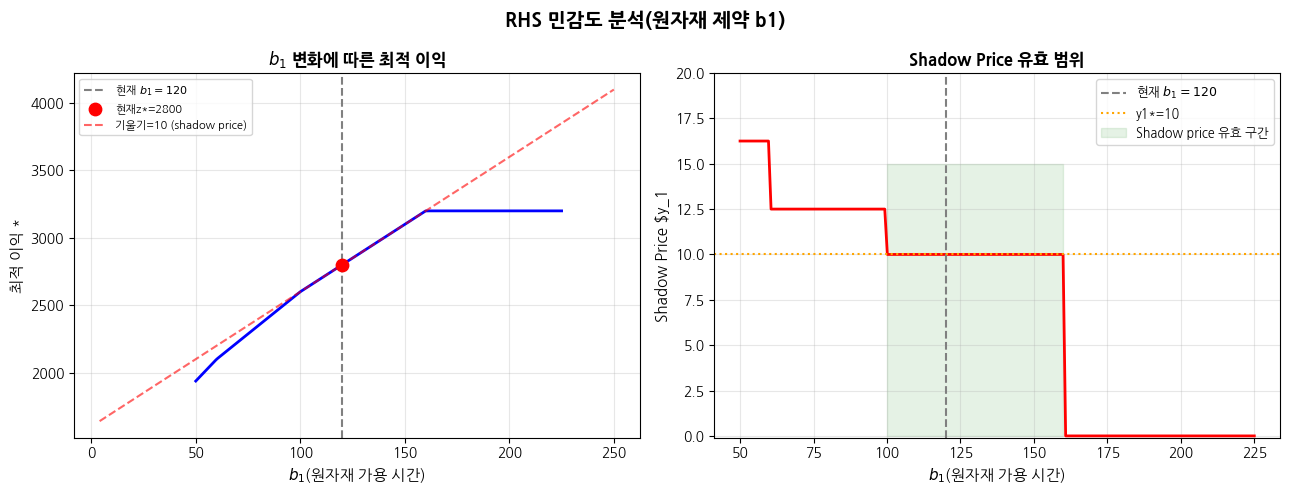

원자재 제약 (b1=120): shadow price y1* = 10.0 만원/kg
노동력 제약 (b2=80): shadow price y2* = 20.0 만원/시간
기계 제약 (b3=100): shadow price y3* = 0.0 만원/시간
-> 원자재 1kg 추가 -> 이익 +10.0만원
-> 노동력 1시간 추가 -> 이익 +20.0만원
-> 기계 1시간 추가 -> 이익 +0.0만원
노동력 인력 확충이 더 효과적!


In [83]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

b1_range = np.linspace(50, 225, 200)
z_b1, sp_b1 = [], []

for b1v in b1_range:
    s = pywraplp.Solver.CreateSolver('GLOP')

    # 결정 변수
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')

    # 제약 조건
    ct1 = s.Add(2*P+Q+3*R <= b1v)
    s.Add(P+2*Q+2*R <= 80)
    s.Add(P+3*Q+1*R <= 100)

    # 목적 함수
    s.Maximize(40*P + 50*Q + 60*R)

    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        z_b1.append(s.Objective().Value())
        sp_b1.append(ct1.dual_value())
        # print(str(b1v),"+", str(ct1.dual_value()) )
    else:
        z_b1.append(np.nan); sp_b1.append(np.nan) 

fig, axes = plt.subplots(1,2, figsize=(13,5))

ax = axes[0]
ax.plot(b1_range, z_b1, 'b-', lw=2)
ax.axvline(120,color='gray', ls='--', label='현재 $b_1=120$')
ax.scatter([120],[2800],color='red', s=80, zorder=5, label='현재z*=2800')
b1_tan=np.array([4,250]) # 기울기 그리는 x값의 범위
ax.plot(b1_tan, 2800+10*(b1_tan-120), 'r--', alpha=0.6, label='기울기=10 (shadow price)')
ax.set_xlabel(r'$b_1$(원자재 가용 시간)', fontsize=11)
ax.set_ylabel('최적 이익 *', fontsize=11)
ax.set_title(r'$b_1$ 변화에 따른 최적 이익', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(b1_range, sp_b1, 'r-', lw=2)
ax.axvline(120, color='gray', ls='--', label='현재 $b_1=120$')
ax.axhline(10, color='orange', ls=':', label='y1*=10')
ax.fill_between([100,160], [0,0], [15,15], alpha=0.1, color='green', label='Shadow price 유효 구간')
ax.set_xlabel(r'$b_1$(원자재 가용 시간)', fontsize=11)
ax.set_ylabel('Shadow Price $y_1', fontsize=11)
ax.set_title('Shadow Price 유효 범위', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-0.1, 20)

plt.suptitle('RHS 민감도 분석(원자재 제약 b1)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('원자재 제약 (b1=120): shadow price y1* = 10.0 만원/kg')
print('노동력 제약 (b2=80): shadow price y2* = 20.0 만원/시간')
print('기계 제약 (b3=100): shadow price y3* = 0.0 만원/시간')
print('-> 원자재 1kg 추가 -> 이익 +10.0만원')
print('-> 노동력 1시간 추가 -> 이익 +20.0만원')
print('-> 기계 1시간 추가 -> 이익 +0.0만원')
print('노동력 인력 확충이 더 효과적!')

b2 변화

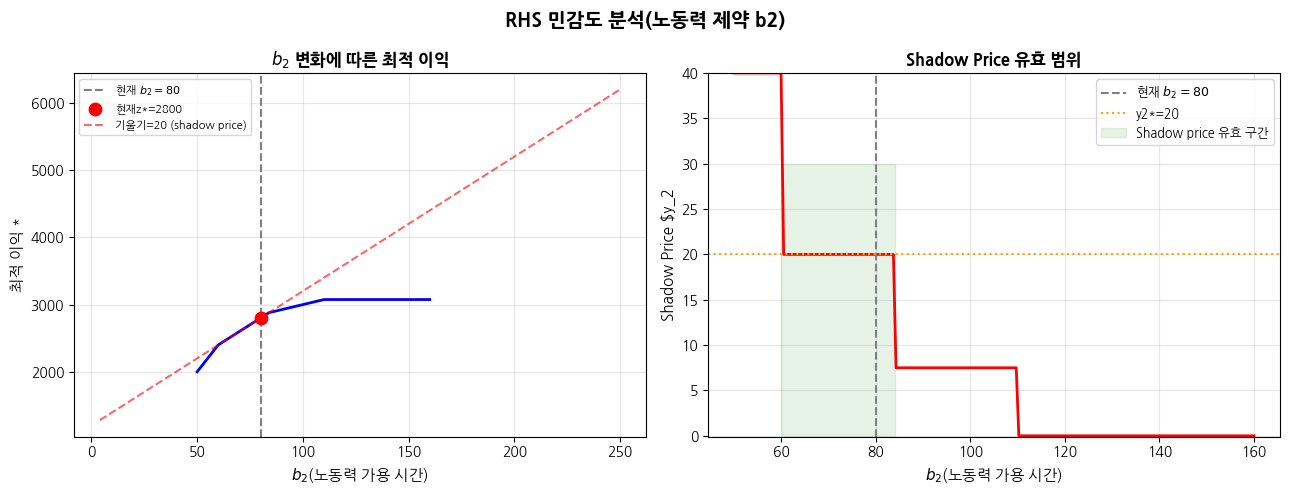

원자재 제약 (b1=120): shadow price y1* = 10.0 만원/kg
노동력 제약 (b2=80): shadow price y2* = 20.0 만원/시간
기계 제약 (b3=100): shadow price y3* = 0.0 만원/시간
-> 원자재 1kg 추가 -> 이익 +10.0만원
-> 노동력 1시간 추가 -> 이익 +20.0만원
-> 기계 1시간 추가 -> 이익 +0.0만원
노동력 인력 확충이 더 효과적!


In [82]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

b2_range = np.linspace(50, 160, 200)
z_b2, sp_b2 = [], []

for b2v in b2_range:
    s = pywraplp.Solver.CreateSolver('GLOP')

    # 결정 변수
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')

    # 제약 조건
    s.Add(2*P+Q+3*R <= 120)
    ct2 = s.Add(P+2*Q+2*R <= b2v)
    s.Add(P+3*Q+1*R <= 100)

    # 목적 함수
    s.Maximize(40*P + 50*Q + 60*R)

    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        z_b2.append(s.Objective().Value())
        sp_b2.append(ct2.dual_value())
        # print(str(b2v),"+", str(ct2.dual_value()) )
    else:
        z_b2.append(np.nan); sp_b2.append(np.nan) 

fig, axes = plt.subplots(1,2, figsize=(13,5))

ax = axes[0]
ax.plot(b2_range, z_b2, 'b-', lw=2)
ax.axvline(80,color='gray', ls='--', label='현재 $b_2=80$')
ax.scatter([80],[2800],color='red', s=80, zorder=5, label='현재z*=2800')
b2_tan=np.array([4,250]) # 기울기 그리는 x값의 범위
ax.plot(b2_tan, 2800+20*(b2_tan-80), 'r--', alpha=0.6, label='기울기=20 (shadow price)')
ax.set_xlabel(r'$b_2$(노동력 가용 시간)', fontsize=11)
ax.set_ylabel('최적 이익 *', fontsize=11)
ax.set_title(r'$b_2$ 변화에 따른 최적 이익', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(b2_range, sp_b2, 'r-', lw=2)
ax.axvline(80, color='gray', ls='--', label='현재 $b_2=80$')
ax.axhline(20, color='orange', ls=':', label='y2*=20')
ax.fill_between([60,84], [0,0], [30,30], alpha=0.1, color='green', label='Shadow price 유효 구간')
ax.set_xlabel(r'$b_2$(노동력 가용 시간)', fontsize=11)
ax.set_ylabel('Shadow Price $y_2', fontsize=11)
ax.set_title('Shadow Price 유효 범위', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-0.1, 40)

plt.suptitle('RHS 민감도 분석(노동력 제약 b2)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('원자재 제약 (b1=120): shadow price y1* = 10.0 만원/kg')
print('노동력 제약 (b2=80): shadow price y2* = 20.0 만원/시간')
print('기계 제약 (b3=100): shadow price y3* = 0.0 만원/시간')
print('-> 원자재 1kg 추가 -> 이익 +10.0만원')
print('-> 노동력 1시간 추가 -> 이익 +20.0만원')
print('-> 기계 1시간 추가 -> 이익 +0.0만원')
print('노동력 인력 확충이 더 효과적!')

b3 변화

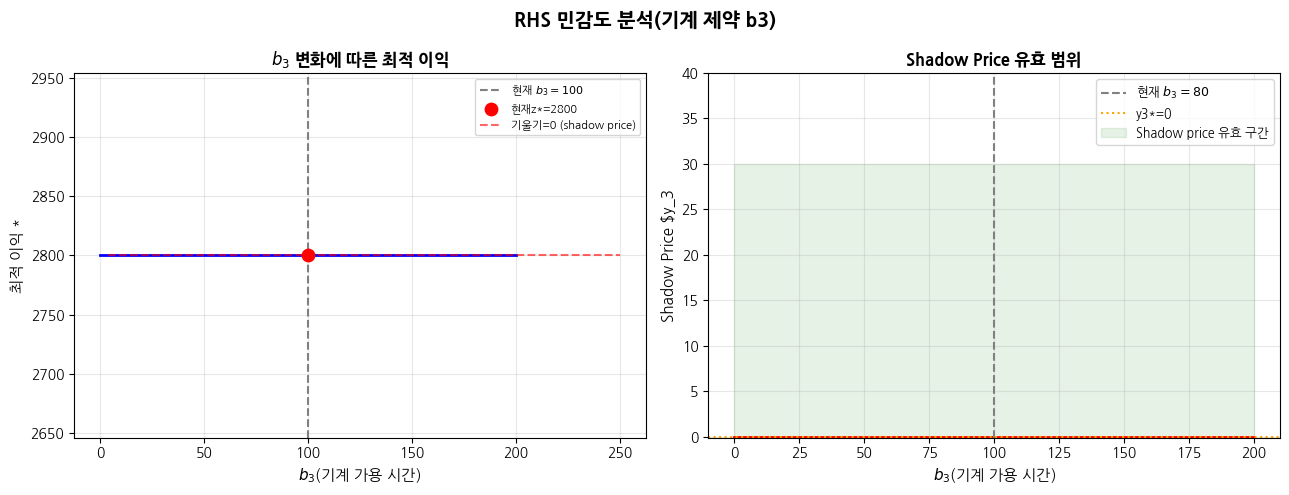

원자재 제약 (b1=120): shadow price y1* = 10.0 만원/kg
노동력 제약 (b2=80): shadow price y2* = 20.0 만원/시간
기계 제약 (b3=100): shadow price y3* = 0.0 만원/시간
-> 원자재 1kg 추가 -> 이익 +10.0만원
-> 노동력 1시간 추가 -> 이익 +20.0만원
-> 기계 1시간 추가 -> 이익 +0.0만원
노동력 인력 확충이 더 효과적!


In [85]:
from ortools.linear_solver import pywraplp
import numpy as np
import matplotlib.pyplot as plt

b3_range = np.linspace(0, 200, 200)
z_b3, sp_b3 = [], []

for b3v in b3_range:
    s = pywraplp.Solver.CreateSolver('GLOP')

    # 결정 변수
    INF = s.infinity()
    P = s.NumVar(0,INF, 'P')
    Q = s.NumVar(0,INF, 'Q')
    R = s.NumVar(0,INF, 'R')

    # 제약 조건
    s.Add(2*P+Q+3*R <= 120)
    s.Add(P+2*Q+2*R <= 80)
    ct3 = s.Add(P+3*Q+1*R <= b2v)

    # 목적 함수
    s.Maximize(40*P + 50*Q + 60*R)

    if s.Solve() ==pywraplp.Solver.OPTIMAL:
        z_b3.append(s.Objective().Value())
        sp_b3.append(ct3.dual_value())
        # print(str(b3v),"+", str(ct3.dual_value()) )
    else:
        z_b3.append(np.nan); sp_b3.append(np.nan) 

fig, axes = plt.subplots(1,2, figsize=(13,5))

ax = axes[0]
ax.plot(b3_range, z_b3, 'b-', lw=2)
ax.axvline(100,color='gray', ls='--', label='현재 $b_3=100$')
ax.scatter([100],[2800],color='red', s=80, zorder=5, label='현재z*=2800')
b3_tan=np.array([4,250]) # 기울기 그리는 x값의 범위
ax.plot(b3_tan, 2800+0*(b3_tan-100), 'r--', alpha=0.6, label='기울기=0 (shadow price)')
ax.set_xlabel(r'$b_3$(기계 가용 시간)', fontsize=11)
ax.set_ylabel('최적 이익 *', fontsize=11)
ax.set_title(r'$b_3$ 변화에 따른 최적 이익', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(b3_range, sp_b3, 'r-', lw=2)
ax.axvline(100, color='gray', ls='--', label='현재 $b_3=80$')
ax.axhline(0, color='orange', ls=':', label='y3*=0')
ax.fill_between([0,200], [0,0], [30,30], alpha=0.1, color='green', label='Shadow price 유효 구간')
ax.set_xlabel(r'$b_3$(기계 가용 시간)', fontsize=11)
ax.set_ylabel('Shadow Price $y_3', fontsize=11)
ax.set_title('Shadow Price 유효 범위', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(-0.1, 40)

plt.suptitle('RHS 민감도 분석(기계 제약 b3)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('원자재 제약 (b1=120): shadow price y1* = 10.0 만원/kg')
print('노동력 제약 (b2=80): shadow price y2* = 20.0 만원/시간')
print('기계 제약 (b3=100): shadow price y3* = 0.0 만원/시간')
print('-> 원자재 1kg 추가 -> 이익 +10.0만원')
print('-> 노동력 1시간 추가 -> 이익 +20.0만원')
print('-> 기계 1시간 추가 -> 이익 +0.0만원')
print('노동력 인력 확충이 더 효과적!')